
  Running simulation  |  L=876mm  θ₀=8.0°  b=0.06  K=0.25

  Pendulum Period — Validation
  Pendulum length   : 876 mm
  Theoretical period: 1.8776 s
  Simulated period  : 1.8867 s
  Error             : 0.488 %


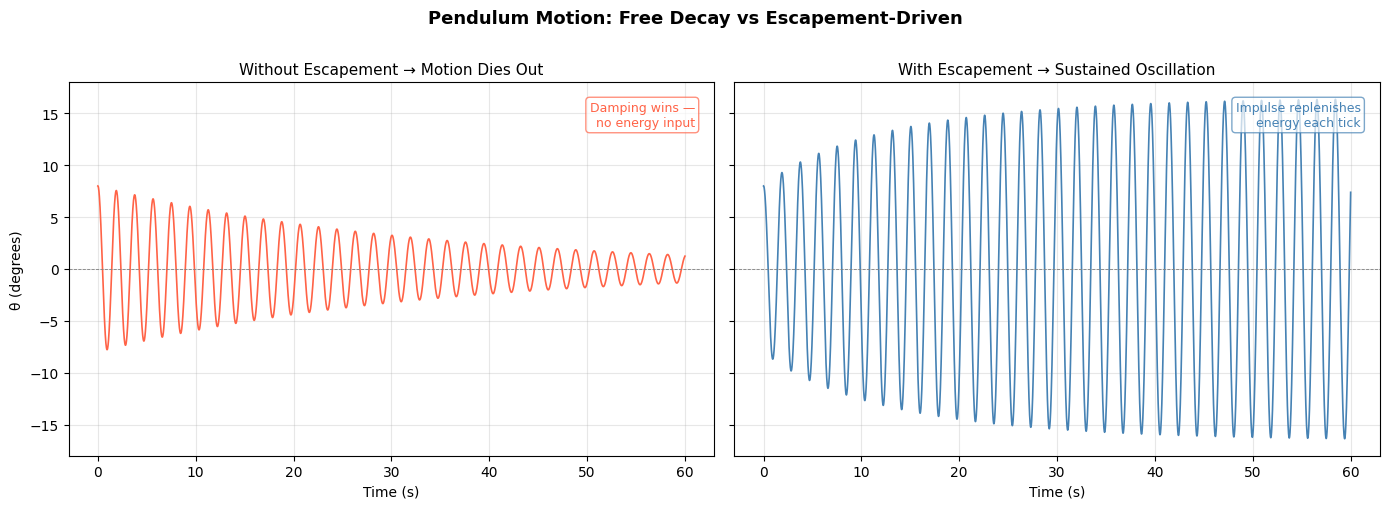

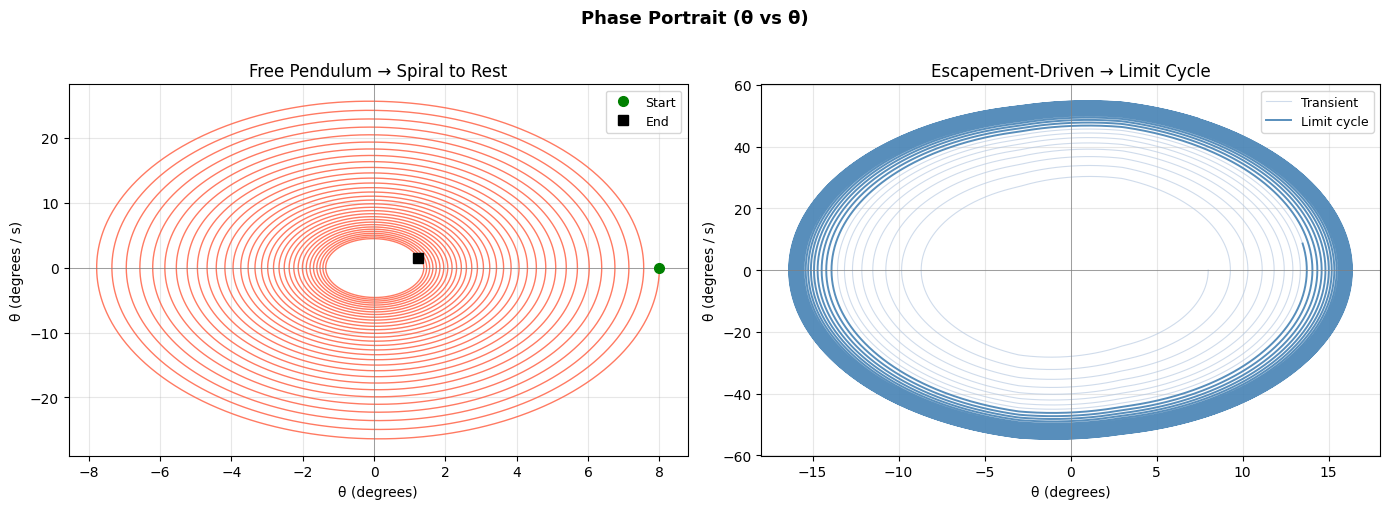

{'T_theory': np.float64(1.877575535112426),
 'T_sim': 1.8867452810533771,
 'error_%': np.float64(0.48838226582464206)}

In [1]:
# =============================================================================
# Deadbeat Escapement Simulation — ME444 Course Project
# =============================================================================
# Simulates a pendulum clock with a deadbeat escapement mechanism.
# Compares free (damped) vs escapement-driven oscillation.
# Validates simulated period against theoretical value.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# =============================================================================
# PARAMETERS — Change only these
# =============================================================================

L          = 0.876   # Pendulum length (m)          — from Clock One build doc
theta0     = 8.0     # Initial angle (degrees)      — typical swing amplitude
damping    = 0.06    # Damping coefficient           — PLA friction estimate
impulse    = 0.25    # Escapement impulse strength   — tune to match prototype
g          = 9.81    # Gravitational acceleration (m/s²)

# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def simulate_pendulum(L, theta0_deg, damping, impulse_strength,
                      t_end=60, escapement=True):
    """
    Simulate nonlinear pendulum with or without escapement.

    Parameters
    ----------
    L               : float — pendulum length in metres
    theta0_deg      : float — initial angle in degrees
    damping         : float — linear damping coefficient
    impulse_strength: float — escapement kick magnitude (ignored if escapement=False)
    t_end           : float — simulation duration in seconds
    escapement      : bool  — True = driven clock, False = free decay

    Returns
    -------
    t, theta, omega : numpy arrays
    """
    omega0       = np.sqrt(g / L)
    theta0       = np.radians(theta0_deg)
    impulse_zone = np.radians(3)   # kick applied within ±3° of centre

    def ode(t, y):
        theta, omega = y
        gravity  = -omega0**2 * np.sin(theta)
        friction = -damping * omega

        kick = 0.0
        if escapement and abs(theta) < impulse_zone:
            kick = impulse_strength * np.sign(omega)

        return [omega, gravity + friction + kick]

    t_eval = np.linspace(0, t_end, t_end * 400)  # 400 pts/sec — smooth enough

    sol = solve_ivp(
        ode,
        t_span=(0, t_end),
        y0=[theta0, 0.0],
        t_eval=t_eval,
        method='RK45',
        rtol=1e-9,
        atol=1e-11,
        max_step=0.005
    )

    return sol.t, sol.y[0], sol.y[1]


def compute_period(t, theta):
    """
    Estimate oscillation period from simulated peaks.
    Uses the second half of the signal to capture steady-state behaviour.

    Returns
    -------
    T_sim : float — mean period in seconds (NaN if not enough peaks)
    """
    half     = len(theta) // 2
    peaks, _ = find_peaks(theta[half:])

    if len(peaks) < 2:
        return float('nan')

    return float(np.mean(np.diff(t[half:][peaks])))


def print_validation(L, T_sim):
    """Print a clean theory vs simulation comparison table."""
    T_theory = 2 * np.pi * np.sqrt(L / g)
    error    = abs(T_sim - T_theory) / T_theory * 100

    print("=" * 45)
    print("  Pendulum Period — Validation")
    print("=" * 45)
    print(f"  Pendulum length   : {L*1000:.0f} mm")
    print(f"  Theoretical period: {T_theory:.4f} s")
    print(f"  Simulated period  : {T_sim:.4f} s")
    print(f"  Error             : {error:.3f} %")
    print("=" * 45)
    return T_theory


# =============================================================================
# PLOT FUNCTIONS
# =============================================================================

def plot_time_series(t_free, theta_free, t_esc, theta_esc):
    """
    Plot 1 — Side-by-side comparison:
        Left  : free pendulum (decaying)
        Right : escapement-driven (sustained)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(
        "Pendulum Motion: Free Decay vs Escapement-Driven",
        fontsize=13, fontweight='bold', y=1.01
    )

    # Free decay
    ax1.plot(t_free, np.degrees(theta_free), color='tomato', lw=1.2)
    ax1.axhline(0, color='grey', lw=0.6, linestyle='--')
    ax1.set_title("Without Escapement → Motion Dies Out", fontsize=11)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("θ (degrees)")
    ax1.grid(True, alpha=0.3)
    ax1.text(
        0.97, 0.95, "Damping wins —\nno energy input",
        transform=ax1.transAxes, ha='right', va='top',
        fontsize=9, color='tomato',
        bbox=dict(boxstyle='round', fc='white', ec='tomato', alpha=0.7)
    )

    # Escapement-driven
    ax2.plot(t_esc, np.degrees(theta_esc), color='steelblue', lw=1.2)
    ax2.axhline(0, color='grey', lw=0.6, linestyle='--')
    ax2.set_title("With Escapement → Sustained Oscillation", fontsize=11)
    ax2.set_xlabel("Time (s)")
    ax2.grid(True, alpha=0.3)
    ax2.text(
        0.97, 0.95, "Impulse replenishes\nenergy each tick",
        transform=ax2.transAxes, ha='right', va='top',
        fontsize=9, color='steelblue',
        bbox=dict(boxstyle='round', fc='white', ec='steelblue', alpha=0.7)
    )

    plt.tight_layout()
    plt.savefig('time_series.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_phase_portrait(t_free, theta_free, omega_free,
                        t_esc,  theta_esc,  omega_esc):
    """
    Plot 2 — Phase portrait (theta vs omega):
        Left  : free pendulum spirals to origin (energy lost)
        Right : escapement-driven converges to a limit cycle (energy balanced)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "Phase Portrait (θ vs θ̇)",
        fontsize=13, fontweight='bold', y=1.01
    )

    # Free — spiral inward
    ax1.plot(np.degrees(theta_free), np.degrees(omega_free),
             color='tomato', lw=1.0, alpha=0.85)
    ax1.plot(np.degrees(theta_free[0]),  np.degrees(omega_free[0]),
             'o', color='green', ms=7, label='Start', zorder=5)
    ax1.plot(np.degrees(theta_free[-1]), np.degrees(omega_free[-1]),
             's', color='black', ms=7, label='End',   zorder=5)
    ax1.set_title("Free Pendulum → Spiral to Rest")
    ax1.set_xlabel("θ (degrees)")
    ax1.set_ylabel("θ̇ (degrees / s)")
    ax1.axhline(0, color='grey', lw=0.5)
    ax1.axvline(0, color='grey', lw=0.5)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Escapement — converge to limit cycle
    cut = len(theta_esc) // 4   # first 25% = transient startup
    ax2.plot(np.degrees(theta_esc[:cut]),  np.degrees(omega_esc[:cut]),
             color='lightsteelblue', lw=0.8, alpha=0.6, label='Transient')
    ax2.plot(np.degrees(theta_esc[cut:]),  np.degrees(omega_esc[cut:]),
             color='steelblue',      lw=1.4, alpha=0.9, label='Limit cycle')
    ax2.set_title("Escapement-Driven → Limit Cycle")
    ax2.set_xlabel("θ (degrees)")
    ax2.set_ylabel("θ̇ (degrees / s)")
    ax2.axhline(0, color='grey', lw=0.5)
    ax2.axvline(0, color='grey', lw=0.5)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase_portrait.png', dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================================
# MAIN — Run everything
# =============================================================================

def run_simulation(L=L, theta0=theta0, damping=damping, impulse=impulse):
    """
    Run the full simulation pipeline.
    Call this function with different arguments to explore parameters.

    Example
    -------
    run_simulation(L=0.5, theta0=10, damping=0.05, impulse=0.2)
    """

    print(f"\n  Running simulation  |  L={L*1000:.0f}mm  "
          f"θ₀={theta0}°  b={damping}  K={impulse}\n")

    # --- Simulate both cases ---
    t_free, theta_free, omega_free = simulate_pendulum(
        L, theta0, damping, impulse,
        t_end=60, escapement=False
    )
    t_esc, theta_esc, omega_esc = simulate_pendulum(
        L, theta0, damping, impulse,
        t_end=60, escapement=True
    )

    # --- Validate ---
    T_sim    = compute_period(t_esc, theta_esc)
    T_theory = print_validation(L, T_sim)

    # --- Plot ---
    plot_time_series(t_free, theta_free, t_esc, theta_esc)
    plot_phase_portrait(t_free, theta_free, omega_free,
                        t_esc,  theta_esc,  omega_esc)

    return {
        'T_theory' : T_theory,
        'T_sim'    : T_sim,
        'error_%'  : abs(T_sim - T_theory) / T_theory * 100
    }


# Run with default prototype parameters
run_simulation()


# =============================================================================
# QUICK PARAMETER EXPLORATION
# Paste any of these into a new Colab cell:
#
#   run_simulation(L=0.5)           # shorter pendulum → faster tick
#   run_simulation(theta0=20)       # larger swing angle
#   run_simulation(impulse=0.1)     # weaker escapement kick → dies out
#   run_simulation(damping=0.15)    # more friction
# =============================================================================


  Running simulation  |  L=876mm  θ₀=8.0°  b=0.06  K=0.25

  Pendulum Period — Validation
  Pendulum length   : 876 mm
  Theoretical period: 1.8776 s
  Simulated period  : 1.8867 s
  Error             : 0.488 %


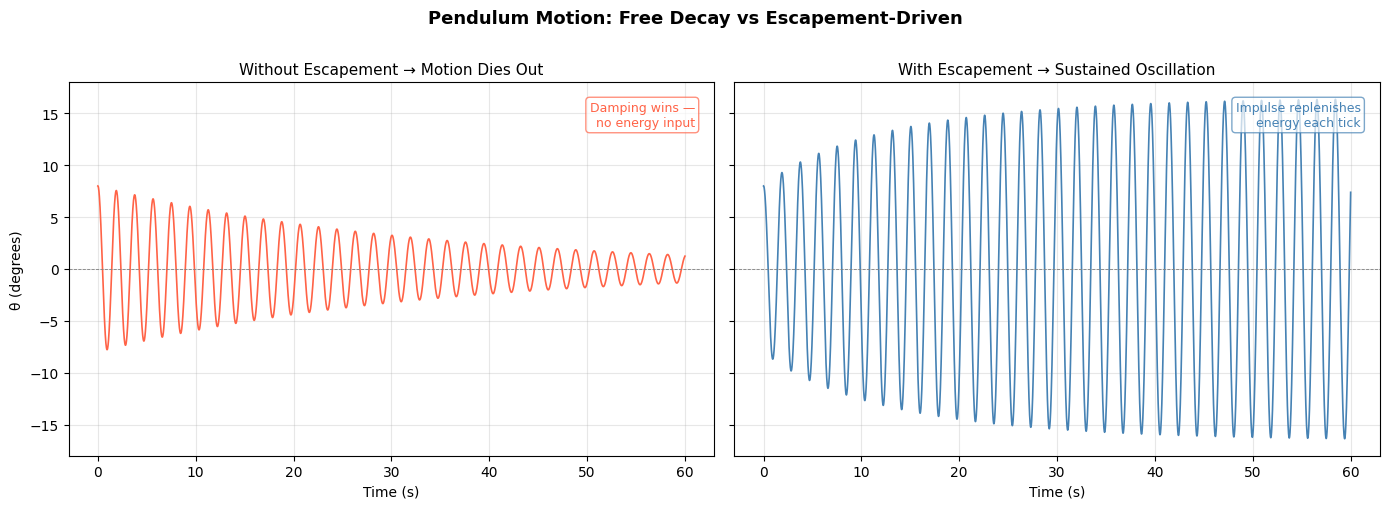

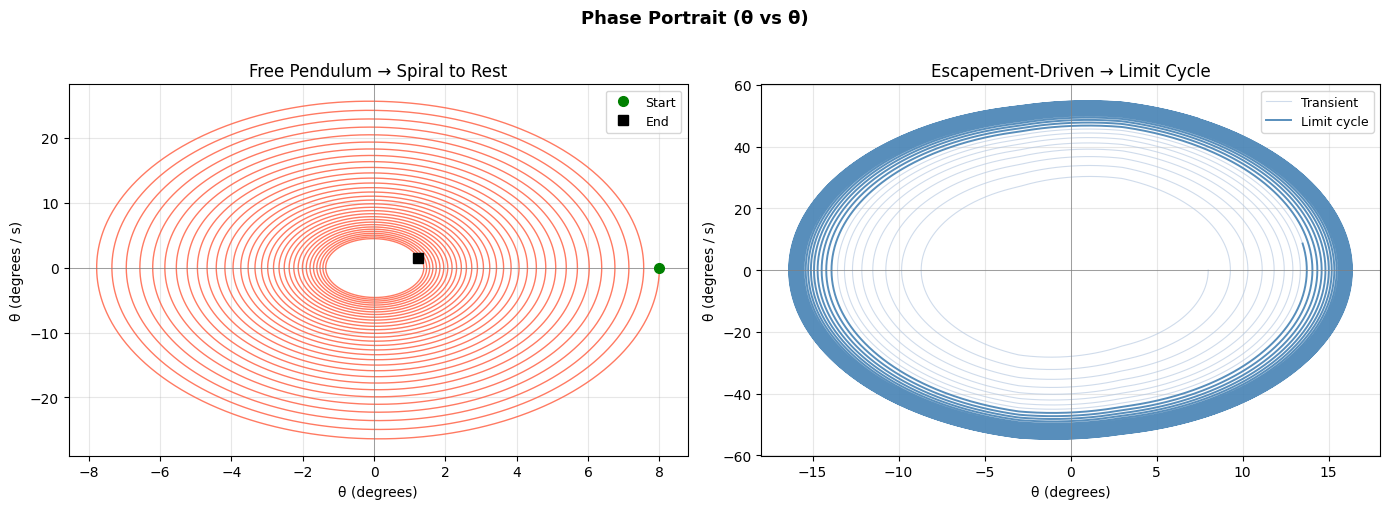


  Running simulation  |  L=876mm  θ₀=8.0°  b=0.06  K=0.1

  Pendulum Period — Validation
  Pendulum length   : 876 mm
  Theoretical period: 1.8776 s
  Simulated period  : 1.8814 s
  Error             : 0.204 %


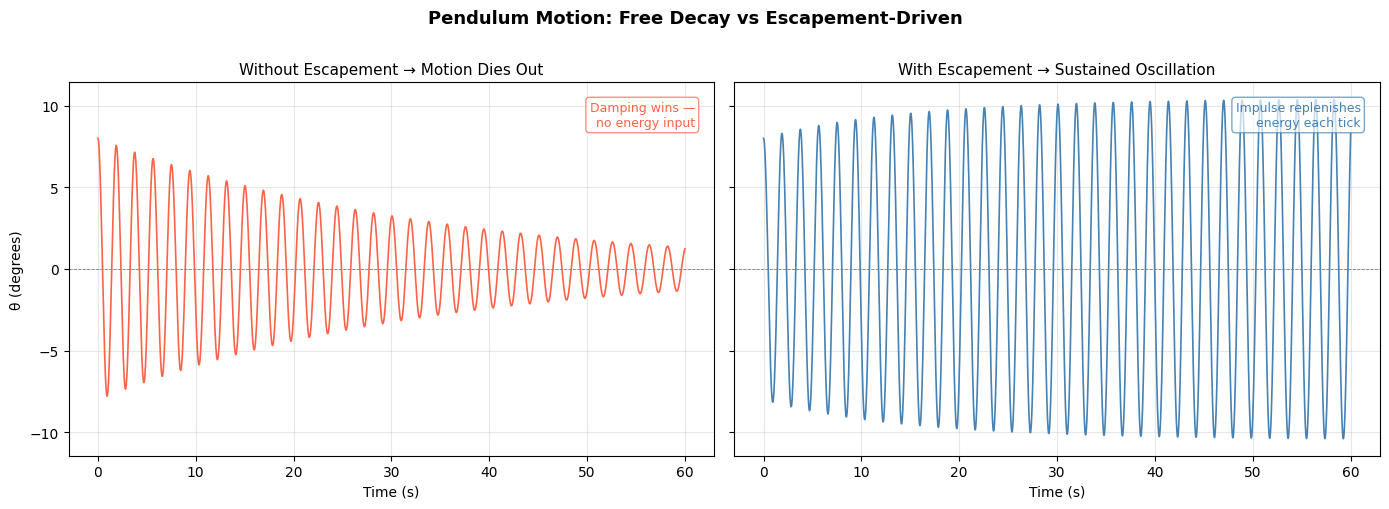

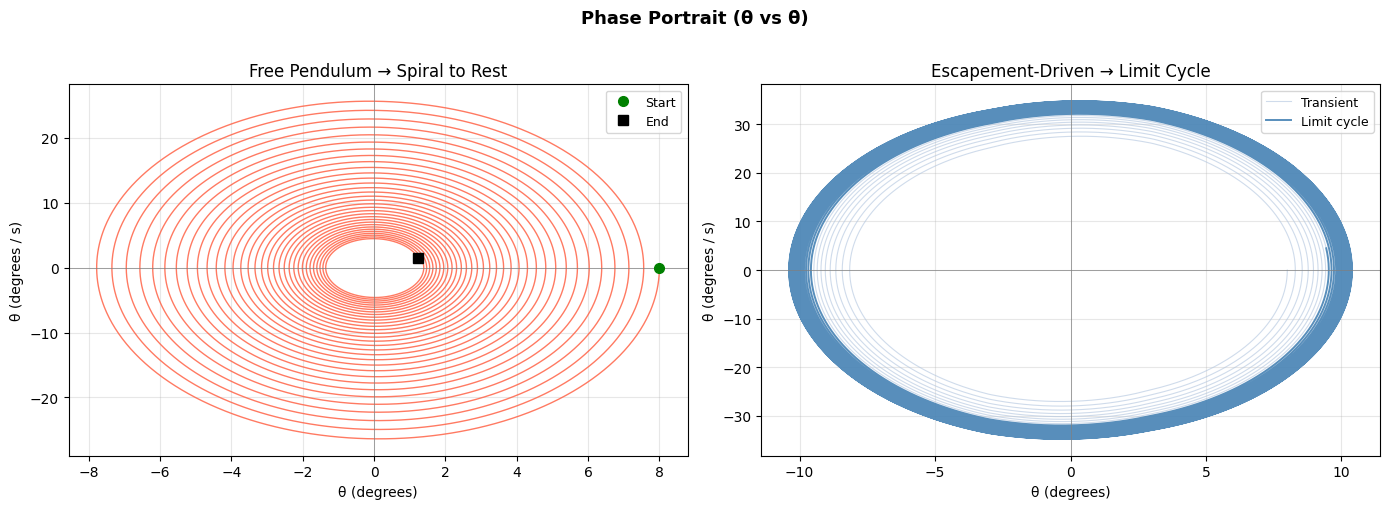


  Running simulation  |  L=500mm  θ₀=8.0°  b=0.06  K=0.25

  Pendulum Period — Validation
  Pendulum length   : 500 mm
  Theoretical period: 1.4185 s
  Simulated period  : 1.4238 s
  Error             : 0.374 %


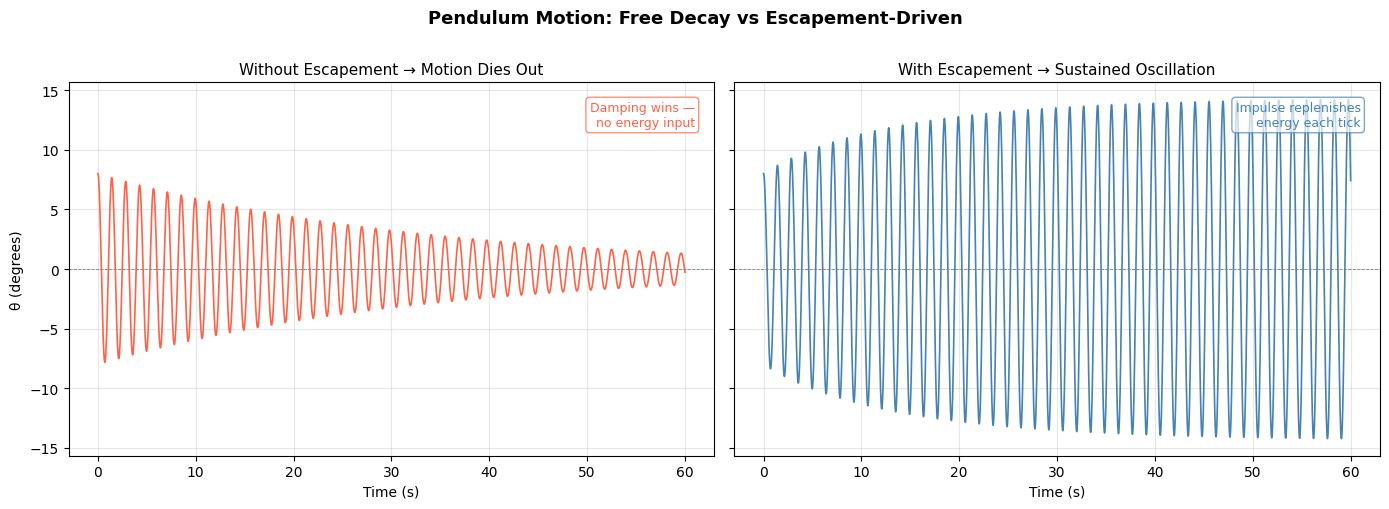

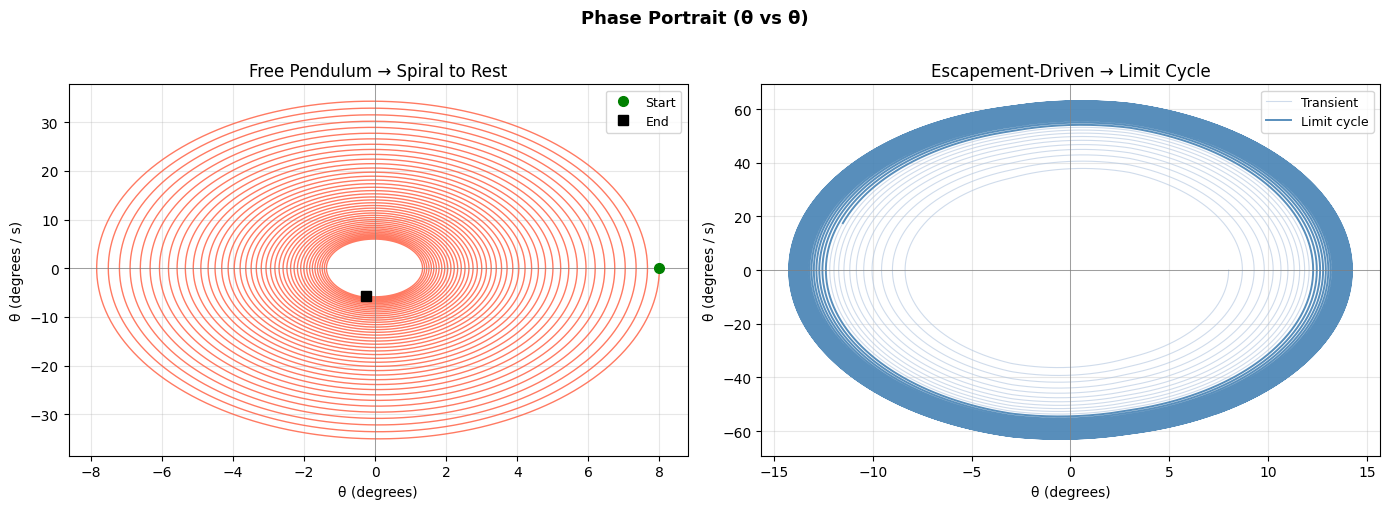


  Running simulation  |  L=876mm  θ₀=8.0°  b=0.15  K=0.25

  Pendulum Period — Validation
  Pendulum length   : 876 mm
  Theoretical period: 1.8776 s
  Simulated period  : 1.8816 s
  Error             : 0.213 %


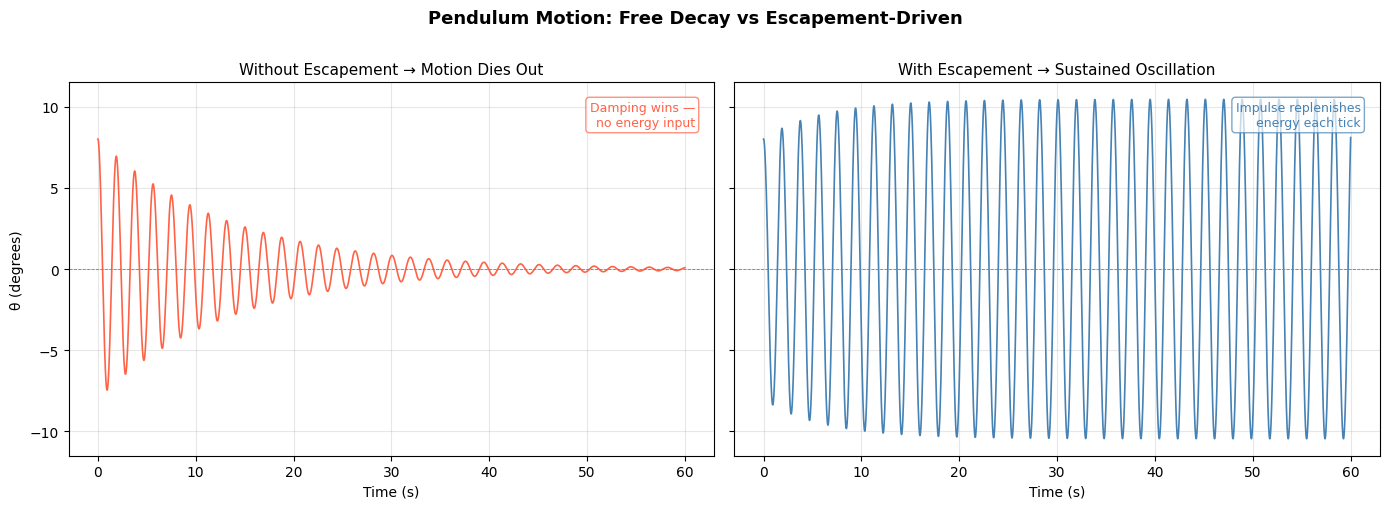

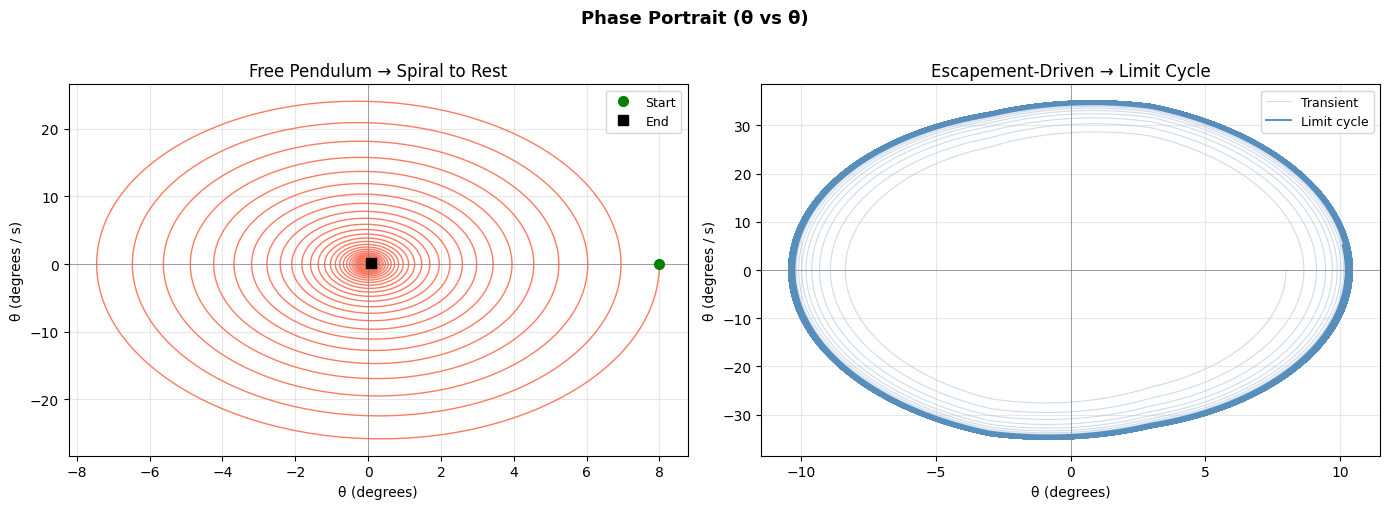

{'T_theory': np.float64(1.877575535112426),
 'T_sim': 1.8815783990999622,
 'error_%': np.float64(0.2131932331178654)}

In [2]:
# Run with your prototype defaults
run_simulation()

# Explore parameters — one change at a time
run_simulation(impulse=0.1)   # too weak → pendulum dies → shows why escapement strength matters
run_simulation(L=0.5)         # shorter pendulum → T ≈ 1.42s vs 1.88s
run_simulation(damping=0.15)  # more friction → needs stronger impulse